# Plotting DES IAU Named SNIa #

Here we will just explore the residuals of only the SNIa that had IAU names as part of the DES data release. This will involve finding patterns between the SNIa resduals and the Host Galaxy Properties found in BLAST.

In [8]:
import numpy as np
import pandas as pd
from astropy.cosmology import FlatwCDM
import matplotlib.pyplot as plt



In [9]:
CSV_PATH = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data/DES_BLAST_results.csv"
data = pd.read_csv(CSV_PATH)
data.head()

,CID,CIDint,IDSURVEY,TYPE,zHEL,zHELERR,zCMB,zCMBERR,zHD,zHDERR,...,blast_local_log_mass_50,blast_local_log_sfr_50,blast_local_log_ssfr_50,blast_local_log_age_50,blast_local_mass_surviving_ratio,blast_global_log_mass_50,blast_global_log_sfr_50,blast_global_log_ssfr_50,blast_global_log_age_50,blast_global_mass_surviving_ratio
0,2001az,153.0,63.0,1.0,0.04069,0.00009,0.04059,0.00009,0.04101,0.00087,...,9.546045,-0.928654,-10.538910,7.554069,0.583209,10.730523,0.568403,-10.164398,7.520495,0.587447
1,2002bf,110.0,63.0,1.0,0.02438,0.00001,0.02494,0.00001,0.02525,0.00085,...,9.997040,-0.925622,-10.907366,7.957052,0.584114,10.786677,0.141385,-10.667980,8.483659,0.571516
2,2003U,195.0,63.0,1.0,0.02810,0.00000,0.02794,0.00000,0.02833,0.00086,...,8.708009,-1.692203,-10.417247,6.886784,0.591237,10.655983,0.455874,-10.195245,7.776826,0.577171
3,2003ch,93.0,63.0,1.0,0.02833,0.00012,0.02895,0.00012,0.02919,0.00087,...,9.096352,-1.163582,-10.298476,7.865943,0.590541,10.995615,-0.953273,-11.951738,10.454021,0.569292
4,2003ic,111.0,63.0,1.0,0.05311,0.00002,0.05196,0.00002,0.05126,0.00088,...,9.538658,-0.617604,-10.123061,7.334700,0.588146,9.789610,0.117596,-9.608736,6.392109,0.639571


### Computing the Model Distance Modulus

- **Define a cosmology:**  
  `COSMO = FlatwCDM(H0=70, Om0=0.3, w0=-1.0)`  
  This sets up a flat ΛCDM universe with Hubble constant \(H_0 = 70\), matter density \(\Omega_m = 0.3\), and dark energy equation-of-state \(w = -1\).


In [10]:
# Define flat ΛCDM cosmology
COSMO = FlatwCDM(H0=70, Om0=0.3, w0=-1.0)

def mu_LCDM(z):
    """Distance modulus μ(z) for flat ΛCDM."""
    z = np.asarray(z, dtype=float)
    return COSMO.distmod(z).value

# Calculate model distance modulus for each supernova
# Then adds it to the data frame that stores the original .csv datafile
data["mu_model"] = mu_LCDM(data["zHD"])

### Removing the Mass Step Correction (DES 5YR Context)

In the DES-SN5YR data release, the Hubble diagram tables (`DES-SN5YR_HD.csv` and `DES-SN5YR_HD+MetaData.csv`) provide
the observed SN distances (`MU`) that is already corrected for its host galaxy mass. 

### Mass Step

The **mass step** is the observed effect that Type Ia supernovae in high-mass host galaxies 
$\log M_\star \geq 10$ appear, after light-curve standardization, to be about 
0.03–0.05 magnitudes brighter than those in lower-mass hosts. 

In cosmology analyses, this is modeled as a step function in host stellar mass, 
shifting the standardized distance modulus by $\pm \tfrac{\gamma}{2}$ depending 
on whether the host is high- or low-mass.

The distance modulus formula that was part of the DES5YR data release is.

$$
\mu \;=\; -2.5 \log_{10}(x_{0}) \;+\; \alpha x_{1} \;-\; \beta c 
\;\pm\; \frac{\gamma}{2} \;-\; \mathrm{biasCor}_{\mu} \;-\; M_{0,\mathrm{avg}}
$$

Please note that $\pm \tfrac{\gamma}{2}$ is the mass step term. Depending on whether the host galaxy is high- or low-mass, we add or subtract this term in order to standardize the brightness (magnitude) of the SNIa supernovae.
NOTE: in the mag scale: higher numbers are dimmer. 

- High mass → add γ/2 → makes μ larger → makes the SN dimmer
- Low mass → subtract γ/2 → makes μ smaller → makes the SN brighter

The issue that we encounter in our analysis is that if the mass step has been accounted for, we end up removing any of the patterns that we can see when looking at anything that relates the host-galaxy mass of the SNIa. So we must undo the correction. 

### Constants 

- Gamma is taken from the DES5YR data release analysis. `Global Parameters` section of the following website:
 https://des-sn-dr.readthedocs.io/en/latest/4_DISTANCES_COVMAT.html

 - Mass Step Details:
    The mass step details were taken from a DES5YR companion paper.
    $P$ is a host galaxy property (most commonly stellar mass $M_\star$), 
    $\gamma$ is the size of the residual "step," and $P_{\text{step}}$ is the 
    threshold at which the division is made — usually fixed at 
    $\log_{10}(M_\star/M_\odot) = 10$.
    Vincenzi et al. (2024), *The Dark Energy Survey: Supernova Cosmology with the Full 5-Year Dataset*.[arXiv:2401.02945](https://arxiv.org/pdf/2401.02945v2)

In [11]:
GAMMA = 0.03754   # DES nuisance parameter
MASS_SPLIT = 10.0 # logM* split point

# Choose your host mass column (DES gives HOST_LOGMASS)
# .astype(float) converts True/False to 1.0/0.0
# is_high_mass is a mask used later.
is_high_mass = (data["HOST_LOGMASS"] >= MASS_SPLIT).astype(float)

# This is ±γ/2: +γ/2 for high-mass, −γ/2 for low-mass
# Remember: is_high_mass is 1.0 for high-mass, 0.0 for low-mass
# This equation adds +0.5*GAMMA for high-mass and −0.5*GAMMA for low-mass
# And the defining point between high and low mass is 10 in logM*. 
delta_massstep = GAMMA * (is_high_mass - 0.5)

# Removes the mass step correction from the observed distance modulus.
# Adds a new collumn to the data frame that restores the mass step correction.
data["mu_noMass"] = data["MU"] - delta_massstep # adding column to df
data["residual"] = data["mu_noMass"] - data["mu_model"] # adding collumn to df
y = data["residual"].astype(float) 


In [12]:
# -------------------
# Feature matrix (BLAST LOCAL + context)
# -------------------
candidate_features = [
    "blast_local_log_mass_50",
    "blast_local_log_sfr_50",
    "blast_local_log_ssfr_50",
    "blast_local_log_age_50",
    "blast_host_redshift",
    "blast_host_EBV_MW",
]

X = data[candidate_features].astype(float)


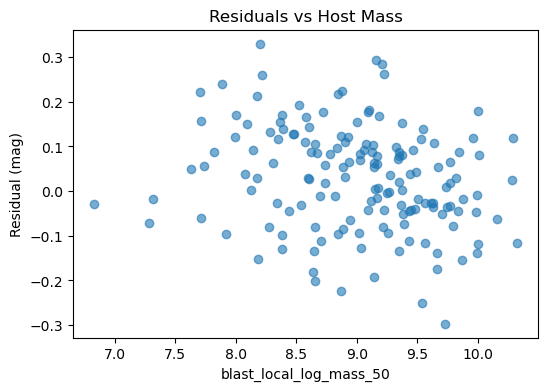

In [13]:
import matplotlib.pyplot as plt

x = data["blast_local_log_mass_50"]   # pick a property
y = data["residual"]              # your residuals (or "RESID")

plt.figure(figsize=(6,4))
plt.plot(x, y, "o", alpha=0.6)        # simple scatter plot
plt.xlabel("blast_local_log_mass_50")
plt.ylabel("Residual (mag)")
plt.title("Residuals vs Host Mass")
plt.show()

161


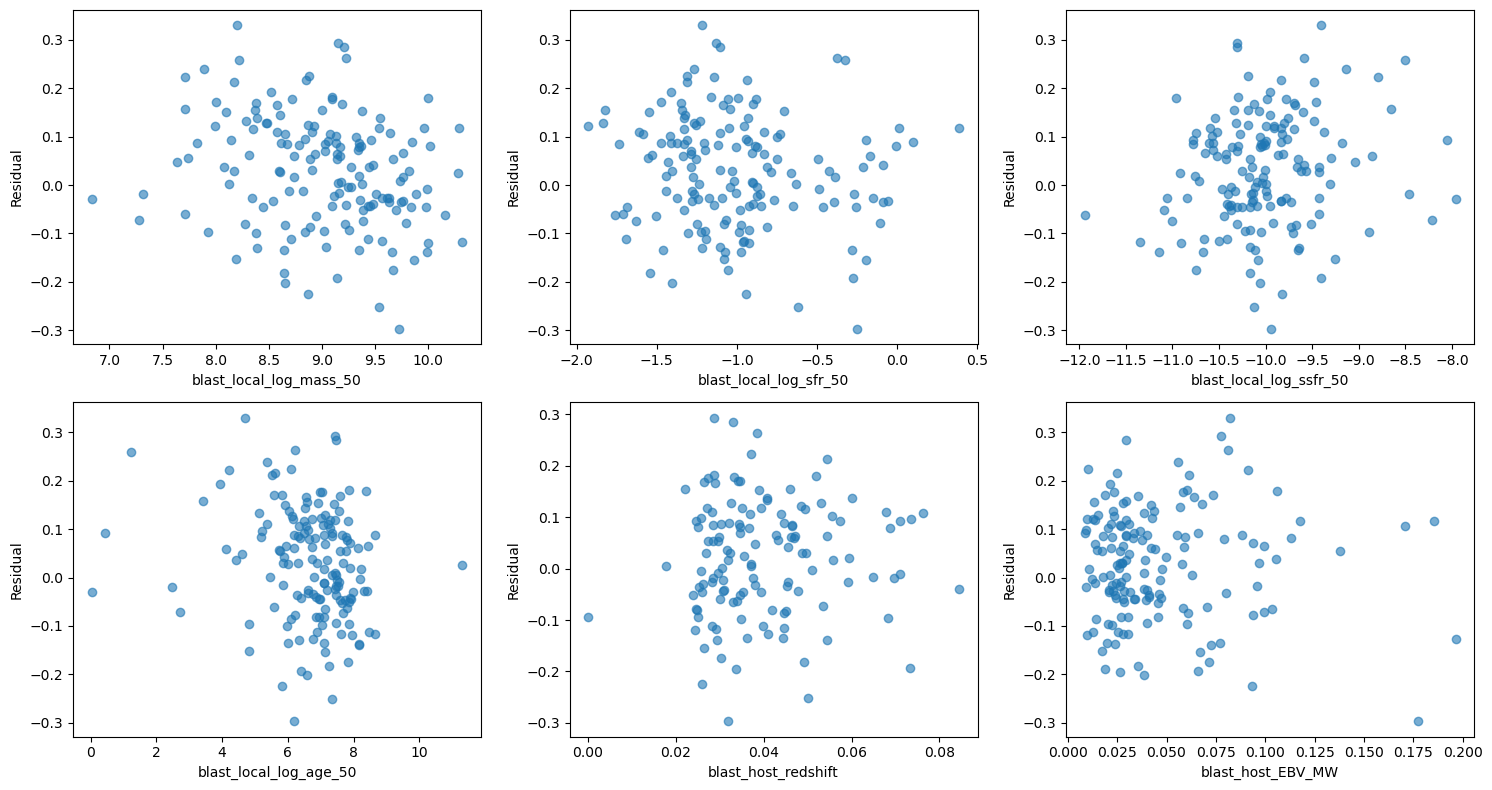

In [14]:
y = data["residual"]   # or "RESID_noMass"
print(len(y))

# make grid
ncols = 3
nrows = int(np.ceil(len(candidate_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))

for i, prop in enumerate(candidate_features):
    ax = axes.flat[i]
    x = data[prop]
    ax.plot(x, y, "o", alpha=0.6)
    ax.set_xlabel(prop)
    ax.set_ylabel("Residual")

# hide any unused axes
for j in range(i+1, nrows*ncols):
    axes.flat[j].axis("off")

plt.tight_layout()
plt.show()